<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/04_model_comparison_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 - Model Comparison (Updated Features)

This notebook is the Week 6 counterpart to `04_model_comparison.ipynb`. It explains the engineered features and school-district join, quantifies old-vs-new feature impact with a controlled Random Forest experiment, and compares Linear Regression, Decision Tree, and Random Forest on the updated feature set.


## Fixed evaluation window

| Split | Period |
|---|---|
| Train | May 2025-April 2026 |
| Validation | May 2026 |
| Test | June 2026 |

Keeping these periods fixed makes the old-vs-new feature comparison interpretable.


In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass

sns.set_theme(style='whitegrid')


Mounted at /content/drive


## 1. Load the fixed June-test split


In [2]:
OUTPUT_DIR = Path(os.getenv('IDX_OUTPUT_DIR', '/content/drive/MyDrive/IDX Exchange/outputs'))
DISTRICT_PATH = Path(os.getenv('IDX_DISTRICT_PATH', '/content/drive/MyDrive/IDX Exchange/DistrictAreas.geojson'))
FEATURE_DIR = OUTPUT_DIR / 'feature_engineering'
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'train': OUTPUT_DIR / 'crmls_sfr_train_X12_2025-05_to_2026-04.csv',
    'validation': OUTPUT_DIR / 'crmls_sfr_validation_2026-05.csv',
    'test': OUTPUT_DIR / 'crmls_sfr_test_2026-06.csv',
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 02 with June data first. Missing: ' + ', '.join(missing))

frames = {name: pd.read_csv(path, low_memory=False) for name, path in paths.items()}
for name, frame in frames.items():
    print(name, frame.shape, paths[name].name)


train (118774, 155) crmls_sfr_train_X12_2025-05_to_2026-04.csv
validation (11984, 155) crmls_sfr_validation_2026-05.csv
test (12827, 155) crmls_sfr_test_2026-06.csv


## 2. Define old and new features

The old feature set represents information available before Week 6. The new set adds ratios, property age, amenity density, seasonal context, and an independently sourced school-district layer.


In [3]:
TARGET = 'ClosePrice'
OLD_NUMERIC_CANDIDATES = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet',
    'LotSizeAcres', 'LotSizeArea', 'YearBuilt', 'GarageSpaces', 'ParkingTotal',
    'Latitude', 'Longitude', 'AssociationFee', 'Stories', 'MainLevelBedrooms',
    'FireplacesTotal',
]
OLD_CATEGORICAL_CANDIDATES = [
    'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor',
    'HighSchoolDistrict', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchoolDistrict', 'Levels',
    'AssociationFeeFrequency', 'StateOrProvince',
]
AMENITY_COLUMNS = [
    'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
    'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN',
]
NEW_NUMERIC = [
    'BedBathRatio', 'PropertyAge', 'LivingAreaToLotRatio',
    'AmenitiesCount', 'CloseMonthSin', 'CloseMonthCos',
]
NEW_CATEGORICAL = ['DistrictName']

OLD_NUMERIC = [c for c in OLD_NUMERIC_CANDIDATES if all(c in f.columns for f in frames.values())]
OLD_CATEGORICAL = [c for c in OLD_CATEGORICAL_CANDIDATES if all(c in f.columns for f in frames.values())]
required = set(AMENITY_COLUMNS + [TARGET, 'CloseDate', 'Latitude', 'Longitude'])
for name, frame in frames.items():
    missing_columns = sorted(required - set(frame.columns))
    if missing_columns:
        raise KeyError(f'{name} is missing required fields: {missing_columns}')
print(f'Leakage-safe base pool: {len(OLD_NUMERIC)} numeric + {len(OLD_CATEGORICAL)} categorical + {len(AMENITY_COLUMNS)} binary fields')


Leakage-safe base pool: 15 numeric + 10 categorical + 7 binary fields


## 3. Engineer property-level features


In [4]:
TRUE_VALUES = {'true', 't', 'yes', 'y', '1'}

def add_property_features(frame):
    result = frame.copy()
    close_date = pd.to_datetime(result['CloseDate'], errors='coerce')
    bedrooms = pd.to_numeric(result['BedroomsTotal'], errors='coerce')
    bathrooms = pd.to_numeric(result['BathroomsTotalInteger'], errors='coerce')
    living_area = pd.to_numeric(result['LivingArea'], errors='coerce')
    lot_size = pd.to_numeric(result['LotSizeSquareFeet'], errors='coerce')
    year_built = pd.to_numeric(result['YearBuilt'], errors='coerce')

    result['BedBathRatio'] = bedrooms / bathrooms.where(bathrooms > 0)
    result['PropertyAge'] = (close_date.dt.year - year_built).clip(lower=0, upper=250)
    result['LivingAreaToLotRatio'] = living_area / lot_size.where(lot_size > 0)
    result['CloseMonthSin'] = np.sin(2 * np.pi * close_date.dt.month / 12)
    result['CloseMonthCos'] = np.cos(2 * np.pi * close_date.dt.month / 12)

    amenity_values = pd.DataFrame(index=result.index)
    for column in AMENITY_COLUMNS:
        amenity_values[column] = (
            result[column].astype(str).str.strip().str.lower().isin(TRUE_VALUES).astype(int)
        )
        result[column] = amenity_values[column]
    result['AmenitiesCount'] = amenity_values.sum(axis=1)
    return result

engineered = {name: add_property_features(frame) for name, frame in frames.items()}
engineered['train'][NEW_NUMERIC].describe().T


,count,mean,std,min,25%,50%,75%,max
BedBathRatio,118736.0,1.458686,0.473016,0.00000,1.000000,1.500000e+00,1.500000,7.500000
PropertyAge,118774.0,49.868751,27.433623,0.00000,28.000000,5.000000e+01,70.000000,225.000000
LivingAreaToLotRatio,118774.0,20.957632,595.966240,0.00016,0.167639,2.364113e-01,0.333391,60566.666667
AmenitiesCount,118774.0,2.232383,1.021722,0.00000,2.000000,2.000000e+00,3.000000,6.000000
CloseMonthSin,118774.0,-0.064696,0.723986,-1.00000,-0.866025,-2.449294e-16,0.500000,1.000000
CloseMonthCos,118774.0,-0.113508,0.677335,-1.00000,-0.866025,-1.836970e-16,0.500000,1.000000


## 4. Spatially join California school districts


In [5]:
if not DISTRICT_PATH.exists():
    raise FileNotFoundError(f'School-district boundary file not found: {DISTRICT_PATH}')

districts = gpd.read_file(DISTRICT_PATH)
if districts.crs is None:
    raise ValueError('The school-district boundary file has no CRS metadata.')

name_candidates = [
    'DistrictName', 'DISTRICT', 'NAME', 'Name', 'district',
    'LEA_NAME', 'UNIFIED', 'SchoolDistrict',
]
district_name_column = next((column for column in name_candidates if column in districts.columns), None)
if district_name_column is None:
    text_columns = [column for column in districts.columns if column != 'geometry' and districts[column].dtype == 'object']
    if not text_columns:
        raise KeyError('Could not identify a district-name column in the boundary file.')
    district_name_column = text_columns[0]

district_lookup = districts[[district_name_column, 'geometry']].rename(columns={district_name_column: 'DistrictName'})

def add_school_district(frame):
    valid_coordinates = frame['Latitude'].notna() & frame['Longitude'].notna()
    result = frame.copy()
    result['DistrictName'] = 'Unknown District'
    points = gpd.GeoDataFrame(
        result.loc[valid_coordinates, ['Latitude', 'Longitude']].copy(),
        geometry=gpd.points_from_xy(
            result.loc[valid_coordinates, 'Longitude'],
            result.loc[valid_coordinates, 'Latitude'],
        ),
        crs='EPSG:4326',
    ).to_crs(district_lookup.crs)
    joined = gpd.sjoin(points, district_lookup, how='left', predicate='within')
    district_values = joined.groupby(level=0)['DistrictName'].first().fillna('Unknown District')
    result.loc[district_values.index, 'DistrictName'] = district_values
    return result

engineered = {name: add_school_district(frame) for name, frame in engineered.items()}

coverage = pd.DataFrame([
    {
        'Split': name,
        'Rows': len(frame),
        'MatchedDistrictRows': int(frame['DistrictName'].ne('Unknown District').sum()),
        'MatchRate_pct': frame['DistrictName'].ne('Unknown District').mean() * 100,
        'UniqueDistricts': frame.loc[frame['DistrictName'].ne('Unknown District'), 'DistrictName'].nunique(),
    }
    for name, frame in engineered.items()
])
display(coverage.style.format({'MatchRate_pct': '{:.2f}%'}))

# Define the primary market population from training data only.
# Full validation/test frames are preserved for robustness reporting.
full_engineered = {name: frame.copy() for name, frame in engineered.items()}
train_reference = full_engineered['train']
price_low, price_high = train_reference[TARGET].quantile([0.005, 0.995])
train_ppsf = train_reference[TARGET] / pd.to_numeric(train_reference['LivingArea'], errors='coerce').where(lambda s: s > 0)
price_ok = train_reference[TARGET].between(price_low, price_high)
ppsf_low, ppsf_high = train_ppsf[price_ok].dropna().quantile([0.005, 0.995])

def primary_population_mask(frame):
    living_area = pd.to_numeric(frame['LivingArea'], errors='coerce')
    ppsf = frame[TARGET] / living_area.where(living_area > 0)
    return frame[TARGET].between(price_low, price_high) & (ppsf.isna() | ppsf.between(ppsf_low, ppsf_high))

engineered = {name: frame.loc[primary_population_mask(frame)].copy() for name, frame in full_engineered.items()}
population_summary = pd.DataFrame([
    {'Split': name.title(), 'FullRows': len(full_engineered[name]), 'PrimaryInRangeRows': len(engineered[name])}
    for name in ['train', 'validation', 'test']
])
display(population_summary)
print(f'Train-defined ClosePrice range: ${price_low:,.0f} to ${price_high:,.0f}')
print(f'Train-defined price/sqft range: ${ppsf_low:,.0f} to ${ppsf_high:,.0f}')


,Split,Rows,MatchedDistrictRows,MatchRate_pct,UniqueDistricts
0,train,118774,118760,99.99%,594
1,validation,11984,11984,100.00%,455
2,test,12827,12827,100.00%,447


,Split,FullRows,PrimaryInRangeRows
0,Train,118774,116424
1,Validation,11984,11735
2,Test,12827,12543


Train-defined ClosePrice range: $190,000 to $8,750,000
Train-defined price/sqft range: $164 to $2,127


## 5. Define shared preprocessing and metrics


In [6]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    ape = np.abs((actual - predicted) / actual)
    return {
        'R2': r2_score(actual, predicted),
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'MAPE_pct': ape.mean() * 100,
        'MdAPE_pct': np.median(ape) * 100,
    }

def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric_features),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            # Group rare labels and cap each field so high-cardinality location
            # columns do not create an excessively wide matrix in Colab.
            ('one_hot', OneHotEncoder(
                handle_unknown='infrequent_if_exist',
                min_frequency=50,
                max_categories=100,
            )),
        ]), categorical_features),
    ])

old_numeric = OLD_NUMERIC + AMENITY_COLUMNS
old_categorical = OLD_CATEGORICAL
new_numeric = OLD_NUMERIC + AMENITY_COLUMNS + NEW_NUMERIC
new_categorical = OLD_CATEGORICAL + NEW_CATEGORICAL


## 6. Controlled old-vs-new feature comparison

The Random Forest configuration and chronological rows remain fixed. Only the input feature set changes.


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# A bounded configuration keeps the controlled comparison practical on Colab CPU.
# Both feature sets use exactly the same settings, so the ablation remains fair.
RF_PARAMS = {
    'n_estimators': 80,
    'max_depth': 24,
    'max_features': 0.7,
    'min_samples_leaf': 2,
    'max_samples': 0.7,
    'n_jobs': -1,
    'random_state': 42,
}

feature_specs = {
    'Old feature set': (old_numeric, old_categorical),
    'Updated feature set': (new_numeric, new_categorical),
}
ablation_rows = []
for feature_set, (numeric_features, categorical_features) in feature_specs.items():
    features = numeric_features + categorical_features
    pipeline = Pipeline([
        ('preprocessing', make_preprocessor(numeric_features, categorical_features)),
        ('model', RandomForestRegressor(**RF_PARAMS)),
    ])
    pipeline.fit(engineered['train'][features], engineered['train'][TARGET])
    for split_name in ['validation', 'test']:
        prediction = pipeline.predict(engineered[split_name][features])
        ablation_rows.append({
            'FeatureSet': feature_set,
            'Split': split_name.title(),
            **regression_metrics(engineered[split_name][TARGET], prediction),
        })

feature_comparison = pd.DataFrame(ablation_rows)
display(feature_comparison.style.format({
    'R2': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
}))


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/l

,FeatureSet,Split,R2,MAE,RMSE,MAPE_pct,MdAPE_pct
0,Old feature set,Validation,0.8789,"$167,684","$330,168",12.39%,8.04%
1,Old feature set,Test,0.8811,"$166,390","$328,959",12.41%,8.09%
2,Updated feature set,Validation,0.8745,"$171,764","$336,092",12.76%,8.23%
3,Updated feature set,Test,0.8758,"$170,932","$336,120",12.83%,8.26%


## 7. Compare models on the updated feature set


In [8]:
updated_features = new_numeric + new_categorical
model_specs = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=18, min_samples_leaf=10, random_state=42),
    'Random Forest': RandomForestRegressor(**RF_PARAMS),
}

models = {}
predictions = {}
model_rows = []
for model_name, estimator in model_specs.items():
    pipeline = Pipeline([
        ('preprocessing', make_preprocessor(
            new_numeric, new_categorical,
            scale_numeric=model_name == 'Linear Regression',
        )),
        ('model', estimator),
    ])
    pipeline.fit(engineered['train'][updated_features], engineered['train'][TARGET])
    models[model_name] = pipeline
    predictions[model_name] = {}
    for split_name in ['validation', 'test']:
        prediction = pipeline.predict(engineered[split_name][updated_features])
        predictions[model_name][split_name] = prediction
        model_rows.append({
            'Model': model_name,
            'Split': split_name.title(),
            **regression_metrics(engineered[split_name][TARGET], prediction),
        })

# Full June is reported separately and is never used for model selection.
for model_name, pipeline in models.items():
    prediction = pipeline.predict(full_engineered['test'][updated_features])
    model_rows.append({
        'Model': model_name,
        'Split': 'Full Test Robustness',
        **regression_metrics(full_engineered['test'][TARGET], prediction),
    })

model_comparison = pd.DataFrame(model_rows)
display(model_comparison.style.format({
    'R2': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
}))
validation_results = model_comparison[model_comparison['Split'].eq('Validation')]
selected_model_name = validation_results.sort_values(['MdAPE_pct', 'MAE']).iloc[0]['Model']
print('Validation-selected model:', selected_model_name)


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/l

,Model,Split,R2,MAE,RMSE,MAPE_pct,MdAPE_pct
0,Linear Regression,Validation,0.7469,"$297,338","$477,316",27.97%,19.72%
1,Linear Regression,Test,0.7515,"$294,506","$475,508",27.62%,19.86%
2,Decision Tree,Validation,0.8178,"$210,171","$404,980",15.60%,10.59%
3,Decision Tree,Test,0.8108,"$210,077","$414,967",15.60%,10.31%
4,Random Forest,Validation,0.8745,"$171,764","$336,092",12.76%,8.23%
5,Random Forest,Test,0.8758,"$170,932","$336,120",12.83%,8.26%
6,Linear Regression,Full Test Robustness,0.5595,"$356,046","$1,002,192",37.94%,20.37%
7,Decision Tree,Full Test Robustness,0.5735,"$270,171","$986,111",24.58%,10.62%
8,Random Forest,Full Test Robustness,0.6014,"$231,924","$953,364",22.77%,8.51%


Validation-selected model: Random Forest


## 8. Visual summaries


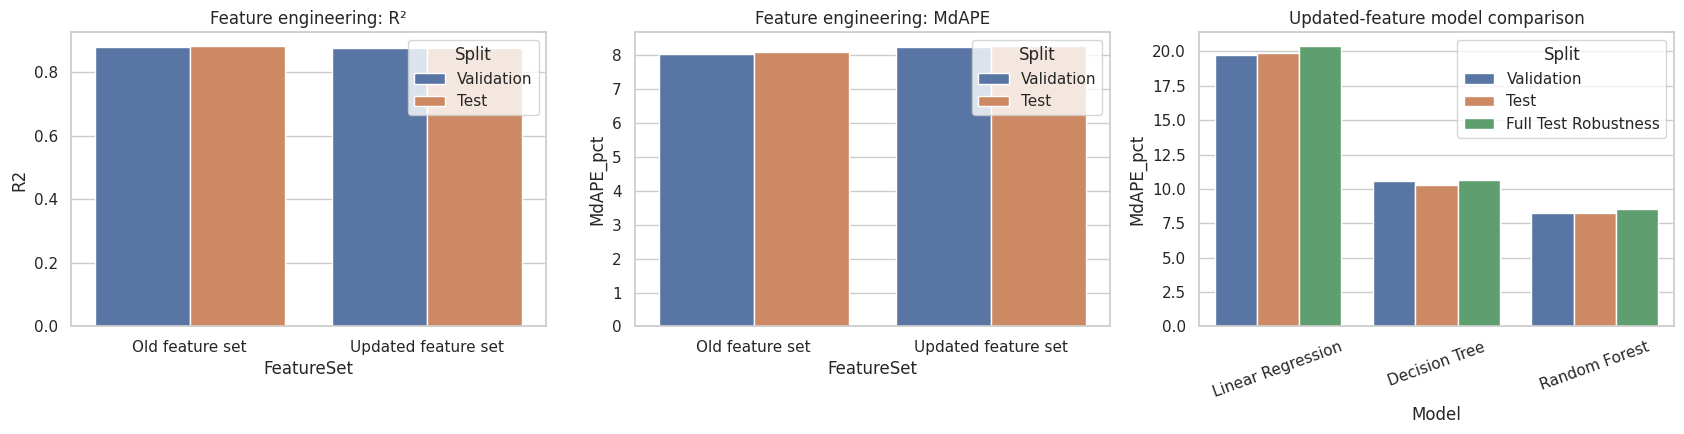

In [9]:
figure, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.barplot(data=feature_comparison, x='FeatureSet', y='R2', hue='Split', ax=axes[0])
axes[0].set_title('Feature engineering: R²')
sns.barplot(data=feature_comparison, x='FeatureSet', y='MdAPE_pct', hue='Split', ax=axes[1])
axes[1].set_title('Feature engineering: MdAPE')
sns.barplot(data=model_comparison, x='Model', y='MdAPE_pct', hue='Split', ax=axes[2])
axes[2].set_title('Updated-feature model comparison')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 9. Save Week 6 deliverables


In [11]:
import joblib

UPDATED_DIR = OUTPUT_DIR / 'week6_updated'
UPDATED_DIR.mkdir(parents=True, exist_ok=True)
feature_comparison.to_csv(UPDATED_DIR / 'old_vs_updated_feature_metrics.csv', index=False)
model_comparison.to_csv(UPDATED_DIR / 'updated_feature_model_comparison.csv', index=False)
coverage.to_csv(UPDATED_DIR / 'school_district_match_summary.csv', index=False)
population_summary.to_csv(UPDATED_DIR / 'evaluation_population_summary.csv', index=False)
joblib.dump(
    {
        'model_name': selected_model_name,
        'model': models[selected_model_name],
        'numeric_features': new_numeric,
        'categorical_features': new_categorical,
        'selection_metric': 'validation MdAPE',
    },
    UPDATED_DIR / 'validation_selected_updated_model.joblib',
)
print('Saved Week 6 deliverables to:', UPDATED_DIR)

Saved Week 6 deliverables to: /content/drive/MyDrive/IDX Exchange/outputs/week6_updated


## Interpretation and limitations

- The controlled table isolates feature-set impact because the rows, months, and Random Forest configuration are identical.
- The model-comparison table answers a separate question: which model performs best after feature engineering.
- School-district membership is geographic context only; it does not measure school quality or establish causality.
- Validation metrics select the preferred model. Test metrics are the final generalization check.
